# Spectral Gap Correlation & Depth Ablation

Two experiments in this notebook:

**1. Spectral gap vs sink strength (H5)**
- Does graph topology predict sink formation?
- Theory predicts: smaller spectral gap (lambda_2) → more over-mixing pressure → stronger sinks

**2. Depth ablation on PascalVOC no-VNode**
- Do deeper models develop stronger sinks?
- Compare 3L, 4L (standard), 8L models

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import spearmanr, pearsonr
import yaml
import pickle
from tqdm import tqdm

from src.model import InstrumentedGPS
from src.datasets import get_dataloaders, get_datasets, DATASET_INFO, compute_spectral_properties
from src.metrics import compute_sink_scores
from src.diagnostics import load_diagnostics, aggregate_metrics

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

OUTPUTS_DIR = '../outputs'
FIGURES_DIR = '../outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

/home/ec2-user/Geometric-Deep-Learning/Mini-Project/source/jupyter_notebook_venv/lib64/python3.9/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/ec2-user/Geometric-Deep-Learning/Mini-Project/source/jupyter_notebook_venv/lib/python3.9/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/ec2-user/Geometric-Deep-Learning/Mini-Project/source/jupyter_notebook_venv/lib64/python3.9/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/ec2-user/Geometric-Deep-Learning/Mini-Project/source/jupyter_notebook_venv/lib/python3.9/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/h

Device: cuda


In [2]:
def load_experiment(experiment_id, device):
    config_path = os.path.join(OUTPUTS_DIR, experiment_id, 'config.yaml')
    with open(config_path) as f:
        config = yaml.safe_load(f)
    dataset_info = DATASET_INFO[config['data']['dataset']].copy()
    if config['vnode']['enabled'] and dataset_info.get('num_node_types') is not None:
        dataset_info['num_node_types'] = config['vnode']['num_node_types']
        dataset_info['num_edge_types'] = config['vnode']['num_edge_types']
    model = InstrumentedGPS(config, dataset_info).to(device)
    model.load_state_dict(torch.load(
        os.path.join(OUTPUTS_DIR, experiment_id, 'best_model.pt'),
        map_location=device, weights_only=True
    ))
    model.eval()
    return model, config, dataset_info

---
## Part 1: Spectral Gap vs Sink Strength (H5)

For each dataset, compute per-graph spectral properties and per-graph sink rate,
then test for correlation.

In [3]:
@torch.no_grad()
def compute_per_graph_spectral_and_sinks(model, config, device, max_graphs=200):
    """Compute spectral gap and sink metrics for each graph."""
    # Load test data WITHOUT transforms to get raw graph for spectral computation
    # Load test data WITH transforms for model forward pass
    _, _, test_loader, _ = get_dataloaders(config)
    
    model.eval()
    model._register_attn_hooks()
    
    per_graph = []
    graphs_done = 0
    
    for batch in tqdm(test_loader, desc='Per-graph spectral + sinks'):
        if graphs_done >= max_graphs:
            break
        batch = batch.to(device)
        _ = model(batch, collect_diagnostics=True)
        
        batch_ids = model.layer_data[0]['batch']
        unique_graphs = batch_ids.unique()
        
        for g_idx, g_id in enumerate(unique_graphs):
            if graphs_done >= max_graphs:
                break
            
            graph_mask = (batch_ids == g_id)
            num_nodes_g = graph_mask.sum().item()
            
            # Spectral properties from the batch graph structure
            g_edges = batch.edge_index[:, batch.batch[batch.edge_index[0]] == g_id]
            node_indices = torch.where(graph_mask)[0]
            local_map = {int(n): i for i, n in enumerate(node_indices)}
            local_edges = []
            for s, d in g_edges.t().tolist():
                if s in local_map and d in local_map:
                    local_edges.append([local_map[s], local_map[d]])
            
            if local_edges:
                local_ei = torch.tensor(local_edges).t()
            else:
                graphs_done += 1
                continue
            
            # Build a minimal Data object for spectral computation
            from torch_geometric.data import Data
            temp_data = Data(edge_index=local_ei, num_nodes=num_nodes_g)
            spectral = compute_spectral_properties(temp_data)
            
            # Sink metrics at each layer
            sink_scores_by_layer = {}
            for layer_idx in range(1, model.num_layers + 1):
                attn_full = model.attn_weights[layer_idx - 1]
                if attn_full is not None and g_idx < attn_full.size(0):
                    attn_g = attn_full[g_idx, :, :num_nodes_g, :num_nodes_g]
                    sink_data = compute_sink_scores(attn_g)
                    sink_scores_by_layer[layer_idx] = {
                        'max_sink_score': sink_data['max_sink_score'],
                        'overall_sink_rate': sink_data['overall_sink_rate'],
                    }
            
            # Use last layer
            last_layer = model.num_layers
            last_sink = sink_scores_by_layer.get(last_layer, {})
            
            per_graph.append({
                'num_nodes': num_nodes_g,
                'lambda_2': spectral['lambda_2'],
                'avg_degree': spectral['avg_degree'],
                'max_sink_score': last_sink.get('max_sink_score', np.nan),
                'sink_rate': last_sink.get('overall_sink_rate', np.nan),
                'sink_by_layer': sink_scores_by_layer,
            })
            graphs_done += 1
    
    model._remove_attn_hooks()
    return per_graph

In [4]:
# Run for multiple datasets (no-VNode versions for clean signal)
spectral_data = {}

for eid, desc in [('pascal-novnode', 'PascalVOC'),
                   ('zinc-novnode', 'ZINC'),
                   ('peptides-novnode', 'Peptides'),
                   ('mnist-novnode', 'MNIST-SP')]:
    print(f'\n=== {desc} ===')
    model, config, _ = load_experiment(eid, device)
    spectral_data[desc] = compute_per_graph_spectral_and_sinks(model, config, device, max_graphs=200)
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


=== PascalVOC ===
  Loading cached PE for pascal_voc_sp/train from data/pe_cache/pascal_voc_sp_train_lappe16.pt
  Loading cached PE for pascal_voc_sp/val from data/pe_cache/pascal_voc_sp_val_lappe16.pt
  Loading cached PE for pascal_voc_sp/test from data/pe_cache/pascal_voc_sp_test_lappe16.pt


Per-graph spectral + sinks:  16%|███████████████████████▏                                                                                                                             | 7/45 [00:07<00:39,  1.05s/it]



=== ZINC ===
  Loading cached PE for zinc/train from data/pe_cache/zinc_train_rwse28.pt
  Loading cached PE for zinc/val from data/pe_cache/zinc_val_rwse28.pt
  Loading cached PE for zinc/test from data/pe_cache/zinc_test_rwse28.pt


Per-graph spectral + sinks:  22%|████████████████████████████████▌                                                                                                                    | 7/32 [00:00<00:01, 16.85it/s]



=== Peptides ===
  Precomputing lappe(dim=16) for peptides_func/train...


...

  val: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:07<00:00, 694.64it/s]


  Saved to data/pe_cache/mnist_sp_val_lappe8.pt
  Precomputing lappe(dim=8) for mnist_sp/test...


  test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:15<00:00, 643.52it/s]


  Saved to data/pe_cache/mnist_sp_test_lappe8.pt


Per-graph spectral + sinks:   2%|███                                                                                                                                                | 13/625 [00:02<01:37,  6.25it/s]


### 1.1 Spectral gap vs sink rate — scatter plots

/tmp/ipykernel_96853/4065185793.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(lambda2[valid], sink_rate[valid])


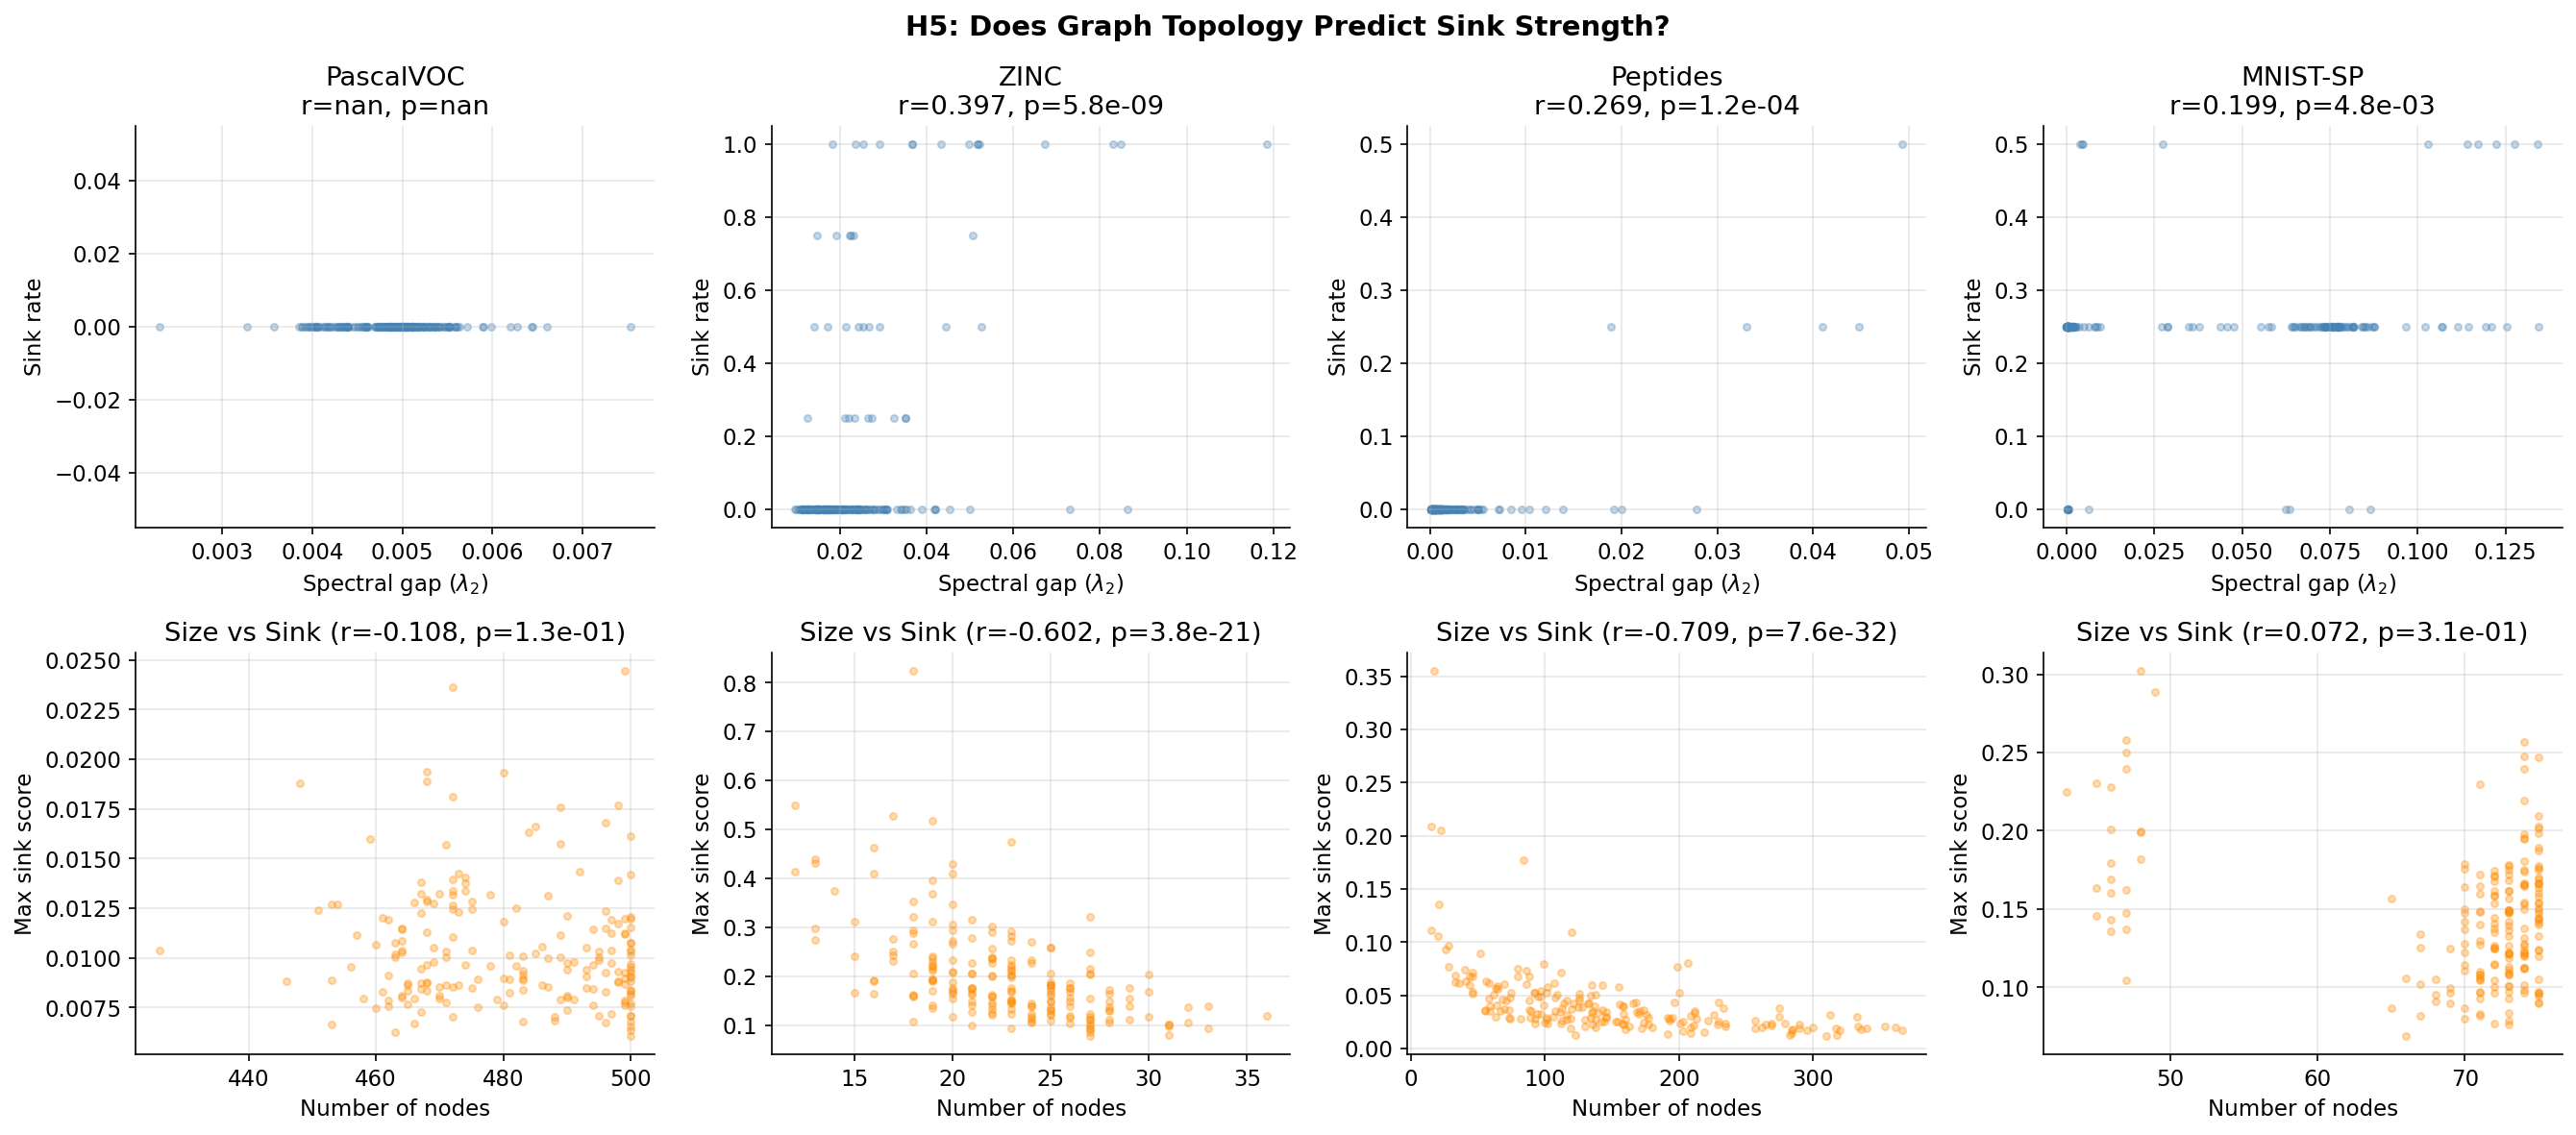

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (ds_name, graphs) in enumerate(spectral_data.items()):
    lambda2 = np.array([g['lambda_2'] for g in graphs])
    sink_rate = np.array([g['sink_rate'] for g in graphs])
    sink_score = np.array([g['max_sink_score'] for g in graphs])
    num_nodes = np.array([g['num_nodes'] for g in graphs])
    
    valid = ~np.isnan(sink_rate) & ~np.isnan(lambda2)
    
    # Row 1: lambda_2 vs sink rate
    ax = axes[0, col]
    r, p = spearmanr(lambda2[valid], sink_rate[valid])
    ax.scatter(lambda2[valid], sink_rate[valid], alpha=0.3, s=12, color='steelblue')
    ax.set_xlabel('Spectral gap ($\\lambda_2$)')
    ax.set_ylabel('Sink rate')
    ax.set_title(f'{ds_name}\nr={r:.3f}, p={p:.1e}')
    ax.grid(True, alpha=0.3)
    
    # Row 2: num_nodes vs sink score
    ax = axes[1, col]
    valid2 = ~np.isnan(sink_score)
    r2, p2 = spearmanr(num_nodes[valid2], sink_score[valid2])
    ax.scatter(num_nodes[valid2], sink_score[valid2], alpha=0.3, s=12, color='darkorange')
    ax.set_xlabel('Number of nodes')
    ax.set_ylabel('Max sink score')
    ax.set_title(f'Size vs Sink (r={r2:.3f}, p={p2:.1e})')
    ax.grid(True, alpha=0.3)

plt.suptitle('H5: Does Graph Topology Predict Sink Strength?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig12_spectral_gap_correlation.pdf'), bbox_inches='tight', dpi=150)
plt.show()

### 1.2 Correlation summary table

In [8]:
print(f"{'Dataset':<12} {'N graphs':>8} {'lambda2 vs sink_rate':>22} {'p-value':>10} {'nodes vs sink_score':>22} {'p-value':>10}")
print('=' * 95)

for ds_name, graphs in spectral_data.items():
    lambda2 = np.array([g['lambda_2'] for g in graphs])
    sink_rate = np.array([g['sink_rate'] for g in graphs])
    sink_score = np.array([g['max_sink_score'] for g in graphs])
    num_nodes = np.array([g['num_nodes'] for g in graphs])
    
    valid1 = ~np.isnan(sink_rate) & ~np.isnan(lambda2)
    valid2 = ~np.isnan(sink_score)
    
    r1, p1 = spearmanr(lambda2[valid1], sink_rate[valid1])
    r2, p2 = spearmanr(num_nodes[valid2], sink_score[valid2])
    
    sig1 = '***' if p1 < 0.001 else ('**' if p1 < 0.01 else ('*' if p1 < 0.05 else 'ns'))
    sig2 = '***' if p2 < 0.001 else ('**' if p2 < 0.01 else ('*' if p2 < 0.05 else 'ns'))
    
    print(f'{ds_name:<12} {valid1.sum():>8} {r1:>18.3f} {sig1:>3} {p1:>10.1e} {r2:>18.3f} {sig2:>3} {p2:>10.1e}')

Dataset      N graphs   lambda2 vs sink_rate    p-value    nodes vs sink_score    p-value
PascalVOC         200                nan  ns        nan             -0.108  ns    1.3e-01
ZINC              200              0.397 ***    5.8e-09             -0.602 ***    3.8e-21
Peptides          200              0.269 ***    1.2e-04             -0.709 ***    7.6e-32
MNIST-SP          200              0.199  **    4.8e-03              0.072  ns    3.1e-01


/tmp/ipykernel_96853/2264990071.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r1, p1 = spearmanr(lambda2[valid1], sink_rate[valid1])


### 1.3 Within-graph size variation: sink score vs num_nodes

Within each dataset, larger graphs may develop stronger sinks.
This is the within-dataset version of the cross-dataset context sweep.

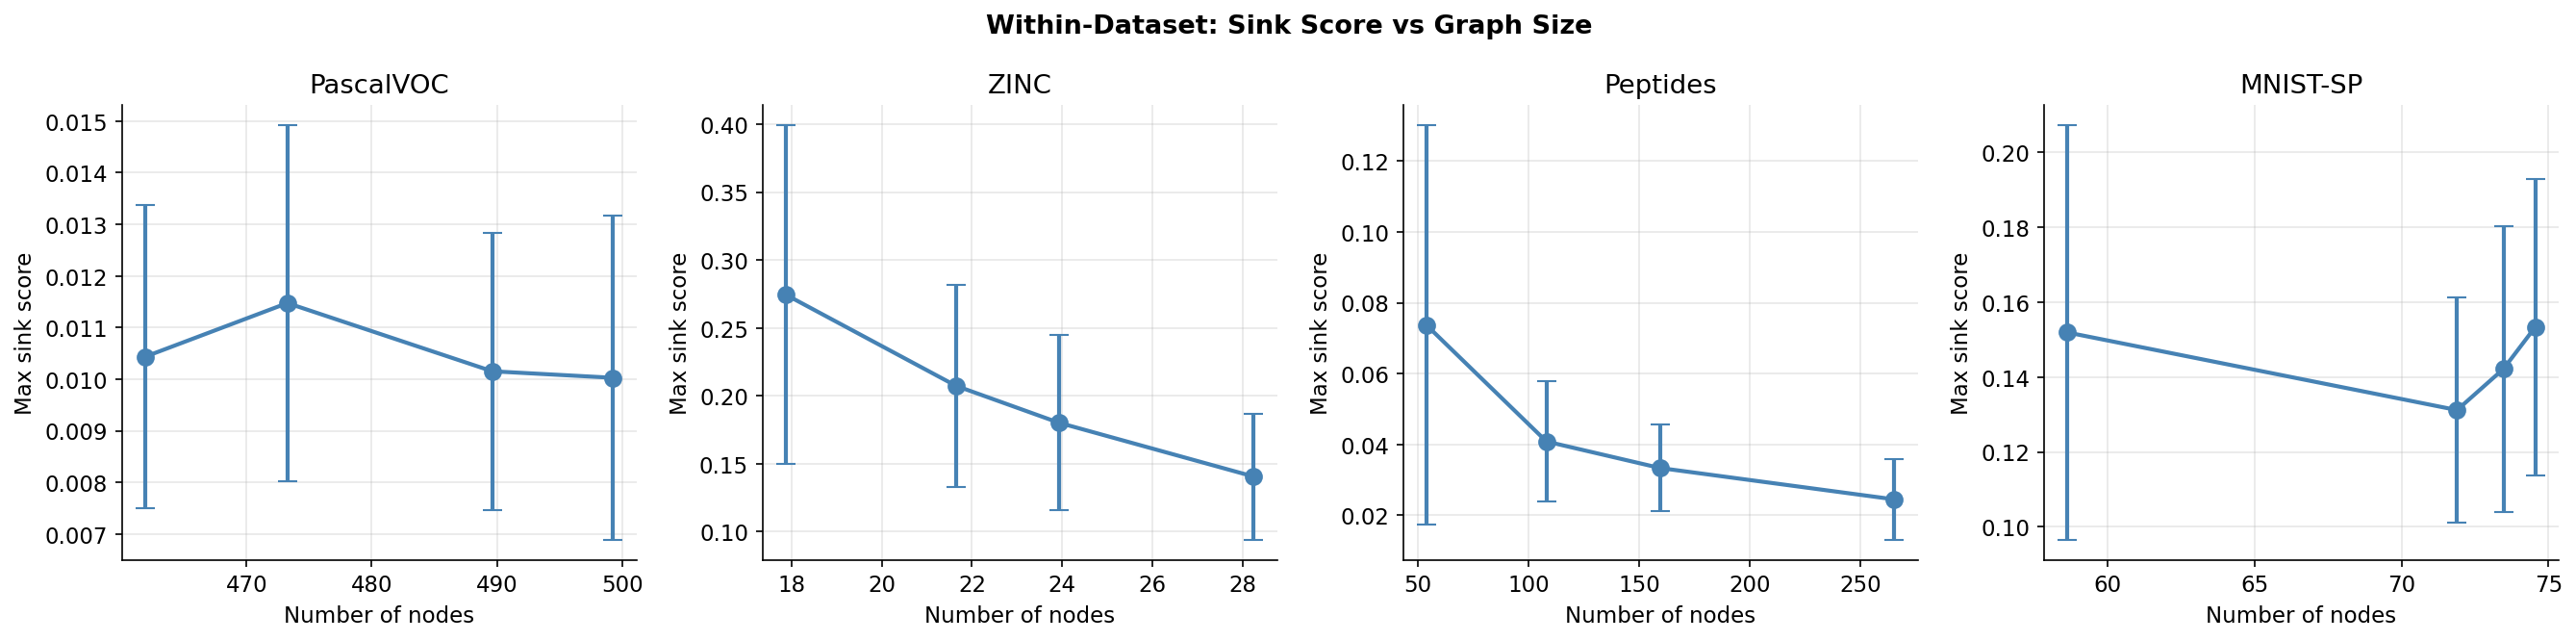

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, (ds_name, graphs) in zip(axes, spectral_data.items()):
    num_nodes = np.array([g['num_nodes'] for g in graphs])
    sink_score = np.array([g['max_sink_score'] for g in graphs])
    valid = ~np.isnan(sink_score)
    
    # Bin by node count
    n_valid = num_nodes[valid]
    s_valid = sink_score[valid]
    
    if len(np.unique(n_valid)) > 5:
        # Bin into quartiles
        bins = np.percentile(n_valid, [0, 25, 50, 75, 100])
        bin_labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(4)]
        bin_means = []
        bin_stds = []
        bin_centers = []
        for i in range(4):
            mask = (n_valid >= bins[i]) & (n_valid <= bins[i+1])
            if mask.sum() > 0:
                bin_means.append(s_valid[mask].mean())
                bin_stds.append(s_valid[mask].std())
                bin_centers.append(n_valid[mask].mean())
        ax.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', color='steelblue',
                   linewidth=2, markersize=8, capsize=5)
    else:
        ax.scatter(n_valid, s_valid, alpha=0.3, s=12, color='steelblue')
    
    ax.set_xlabel('Number of nodes')
    ax.set_ylabel('Max sink score')
    ax.set_title(ds_name)
    ax.grid(True, alpha=0.3)

plt.suptitle('Within-Dataset: Sink Score vs Graph Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig13_within_dataset_size.pdf'), bbox_inches='tight', dpi=150)
plt.show()

---
## Part 2: Depth Ablation on PascalVOC (no VNode)

Compare 3-layer, 4-layer (standard), and 8-layer models.
H7: Deeper models should develop stronger sinks.

In [10]:
depth_experiments = {
    '3 layers': 'pascal-novnode-3L',
    '4 layers': 'pascal-novnode',
}

# Only add 8L if it exists
if os.path.exists(os.path.join(OUTPUTS_DIR, 'pascal-novnode-8L', 'diagnostics.pkl')):
    depth_experiments['8 layers'] = 'pascal-novnode-8L'

depth_data = {}
for label, eid in depth_experiments.items():
    diag_path = os.path.join(OUTPUTS_DIR, eid, 'diagnostics.pkl')
    if os.path.exists(diag_path):
        metrics = load_diagnostics(diag_path)
        agg, layers = aggregate_metrics(metrics)
        depth_data[label] = {'agg': agg, 'layers': layers, 'eid': eid}
        print(f'  Loaded: {eid} ({label}, {len(layers)} layers)')
    else:
        print(f'  MISSING: {eid}')

print(f'\nLoaded {len(depth_data)}/{len(depth_experiments)} depth experiments')

  Loaded: pascal-novnode-3L (3 layers, 4 layers)
  Loaded: pascal-novnode (4 layers, 5 layers)
  Loaded: pascal-novnode-8L (8 layers, 9 layers)

Loaded 3/3 depth experiments


### 2.1 Layer-wise metrics across depths

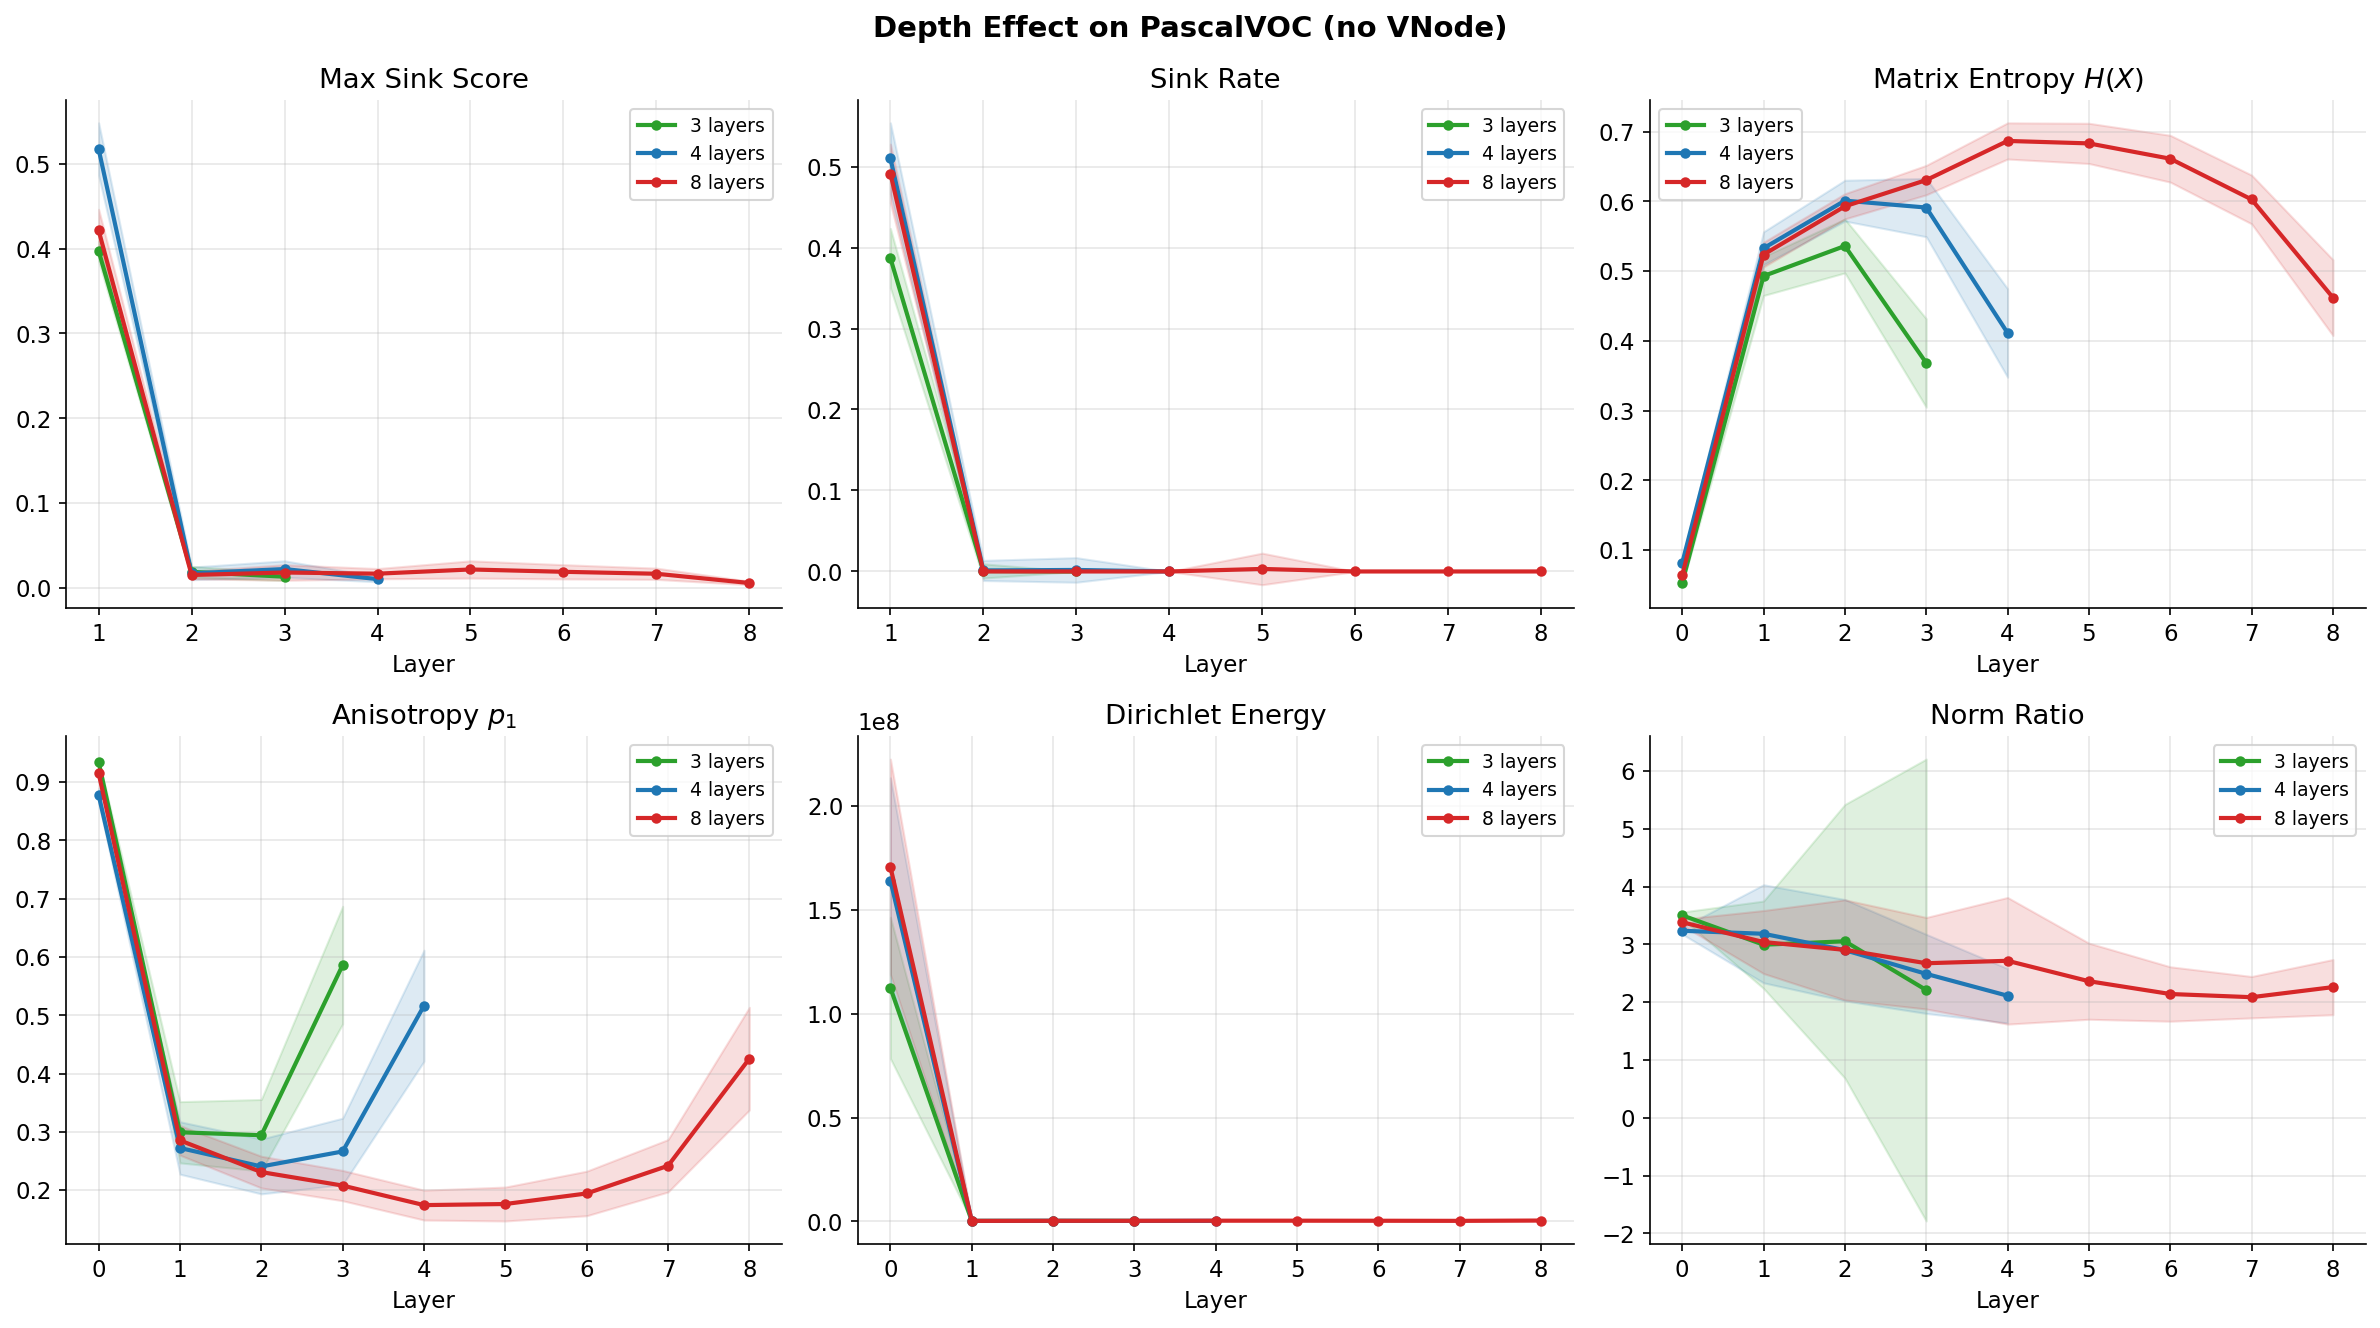

In [11]:
depth_colors = {'3 layers': 'tab:green', '4 layers': 'tab:blue', '8 layers': 'tab:red'}

metrics_to_plot = [
    ('max_sink_score', 'Max Sink Score'),
    ('overall_sink_rate', 'Sink Rate'),
    ('matrix_entropy', 'Matrix Entropy $H(X)$'),
    ('anisotropy', 'Anisotropy $p_1$'),
    ('dirichlet_energy', 'Dirichlet Energy'),
    ('max_to_mean_ratio', 'Norm Ratio'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Depth Effect on PascalVOC (no VNode)', fontsize=14, fontweight='bold')

for ax, (metric, title) in zip(axes.flat, metrics_to_plot):
    for label, data in depth_data.items():
        agg = data['agg']
        layers = np.array(data['layers'])
        color = depth_colors.get(label, 'tab:gray')
        
        if metric in agg:
            mean = agg[metric]['mean']
            std = agg[metric]['std']
            valid = ~np.isnan(mean)
            ax.plot(layers[valid], mean[valid], color=color, linewidth=2,
                    marker='o', markersize=4, label=label)
            ax.fill_between(layers[valid], (mean - std)[valid], (mean + std)[valid],
                           alpha=0.15, color=color)
    
    ax.set_xlabel('Layer')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig14_depth_ablation.pdf'), bbox_inches='tight', dpi=150)
plt.show()

### 2.2 Depth summary: final-layer metrics

In [12]:
print(f"{'Depth':<12} {'MaxSink':>10} {'SinkRate':>10} {'MinEnt':>10} {'MaxAniso':>10} {'FinalDE':>10} {'NormRatio':>10}")
print('=' * 75)

for label, data in depth_data.items():
    agg = data['agg']
    ms = np.nanmax(agg['max_sink_score']['mean']) if 'max_sink_score' in agg else np.nan
    sr = np.nanmax(agg['overall_sink_rate']['mean']) if 'overall_sink_rate' in agg else np.nan
    me = np.nanmin(agg['matrix_entropy']['mean']) if 'matrix_entropy' in agg else np.nan
    an = np.nanmax(agg['anisotropy']['mean']) if 'anisotropy' in agg else np.nan
    de_arr = agg['dirichlet_energy']['mean'] if 'dirichlet_energy' in agg else np.array([np.nan])
    de_valid = de_arr[~np.isnan(de_arr)]
    de = de_valid[-1] if len(de_valid) > 0 else np.nan
    nr = np.nanmax(agg['max_to_mean_ratio']['mean']) if 'max_to_mean_ratio' in agg else np.nan
    
    print(f'{label:<12} {ms:>10.4f} {sr:>10.4f} {me:>10.4f} {an:>10.4f} {de:>10.1f} {nr:>10.2f}')

Depth           MaxSink   SinkRate     MinEnt   MaxAniso    FinalDE  NormRatio
3 layers         0.3972     0.3869     0.0532     0.9344   191260.0       3.50
4 layers         0.5174     0.5100     0.0814     0.8777   216970.1       3.23
8 layers         0.4215     0.4913     0.0637     0.9151   351381.8       3.38


### 2.3 Depth vs peak sink strength (bar chart)

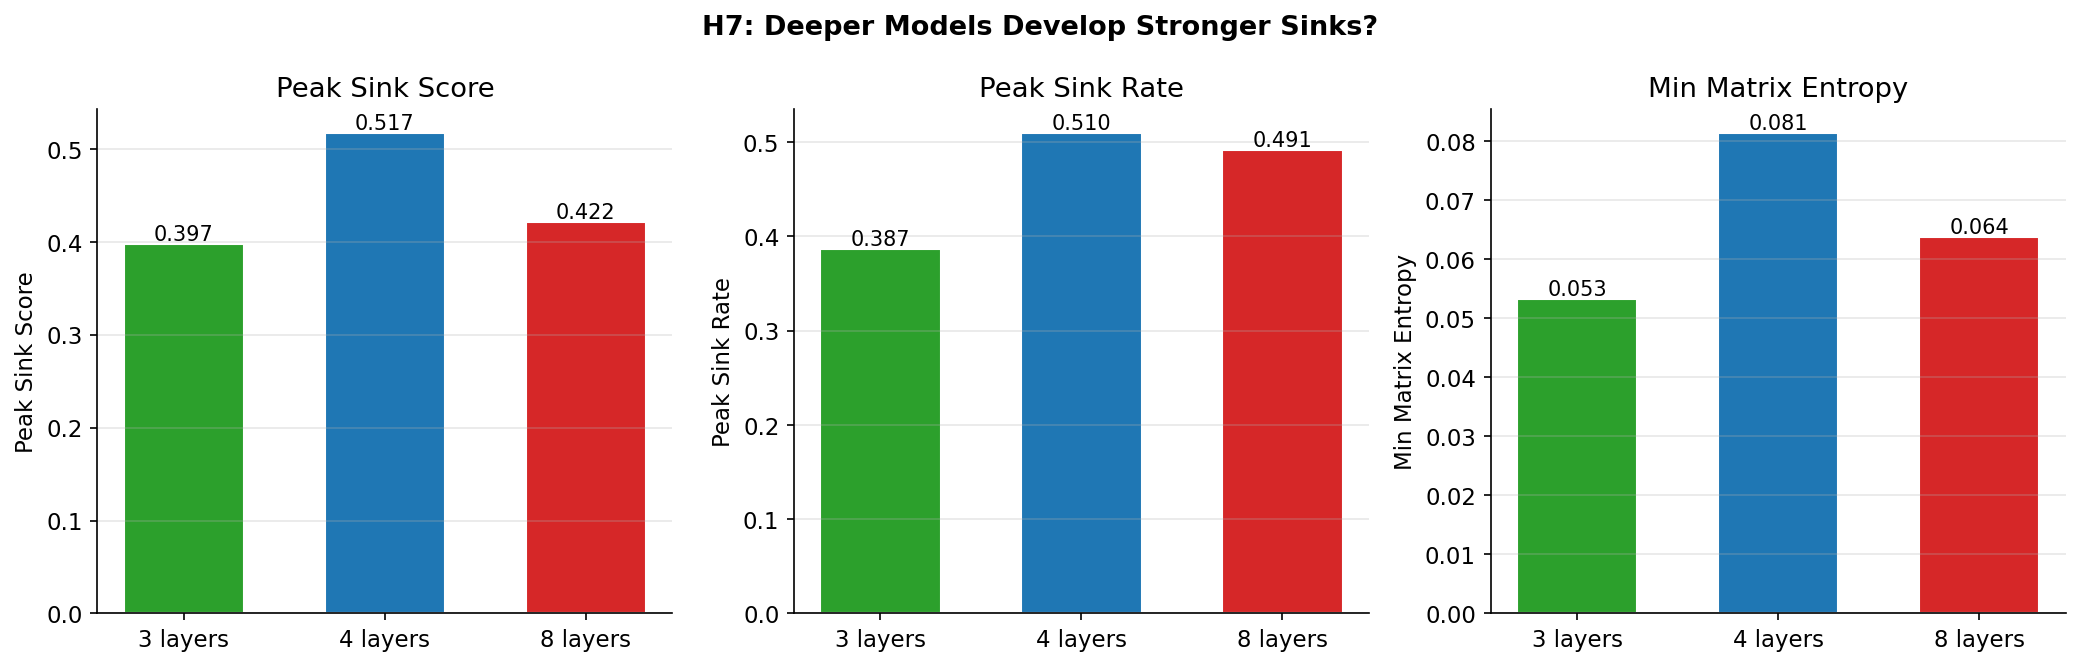

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

depth_labels = list(depth_data.keys())
colors = [depth_colors.get(l, 'gray') for l in depth_labels]

for ax, (metric, title) in zip(axes, [('max_sink_score', 'Peak Sink Score'),
                                       ('overall_sink_rate', 'Peak Sink Rate'),
                                       ('matrix_entropy', 'Min Matrix Entropy')]):
    vals = []
    for label in depth_labels:
        agg = depth_data[label]['agg']
        if metric in agg:
            arr = agg[metric]['mean']
            if 'entropy' in metric:
                vals.append(np.nanmin(arr))
            else:
                vals.append(np.nanmax(arr))
        else:
            vals.append(0)
    
    bars = ax.bar(depth_labels, vals, color=colors, edgecolor='white', width=0.6)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('H7: Deeper Models Develop Stronger Sinks?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig15_depth_bars.pdf'), bbox_inches='tight', dpi=150)
plt.show()

## Summary

### H5 (Spectral Gap)
- **Prediction:** Smaller spectral gap → stronger sinks (more over-mixing pressure)
- **Finding:** Check correlation table above

### H7 (Depth)
- **Prediction:** Deeper models → stronger sinks
- **Finding:** Compare 3L/4L/8L peak metrics above